# Testes

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

from datasets import Dataset, features

from llm_mri import ActivationAreas, Evaluation
from llm_mri.dimensionality_reduction import PCA, UMAP, SVD

In [2]:
def get_layer_number(node_name):
    return int(node_name.split("_")[0])

def get_num_nodes_per_layer(graph):
    nodes_per_layer = dict()
    for node in graph.nodes():
        layer = get_layer_number(node)
        if layer in nodes_per_layer:
            nodes_per_layer[layer] += 1
        else:
            nodes_per_layer[layer] = 1
    return nodes_per_layer

In [3]:
# max number of edger 
current_graph = nx.read_gexf(f"data/interim/graphs/complete/g_I_bigram_shift.gexf")
num_nodes_per_layer = get_num_nodes_per_layer(current_graph)
total = 1
for layer, num_nodes in num_nodes_per_layer.items():
  total *= num_nodes
print("Max number of edges:", total)
print("Number of edges in the graph:", current_graph.number_of_edges())

Max number of edges: 563419249733543314176000
Number of edges in the graph: 10938


In [4]:
import pandas as pd
import networkx as nx

# Supondo que 'G' seja o seu grafo
# Extraímos apenas os valores do atributo 'weight'
weights = [d['weight'] for u, v, d in current_graph.edges(data=True)]

# Criamos o DataFrame de frequências
df_freq = pd.Series(weights).value_counts().reset_index()
df_freq.columns = ['weight', 'frequencia']

# Opcional: ordenar pelo valor do peso
df_freq = df_freq.sort_values(by='weight').reset_index(drop=True)

print(df_freq)

     weight  frequencia
0       1.0        4802
1       2.0        1917
2       3.0        1094
3       4.0         570
4       5.0         402
..      ...         ...
109   165.0           1
110   167.0           1
111   184.0           1
112   198.0           1
113   218.0           1

[114 rows x 2 columns]


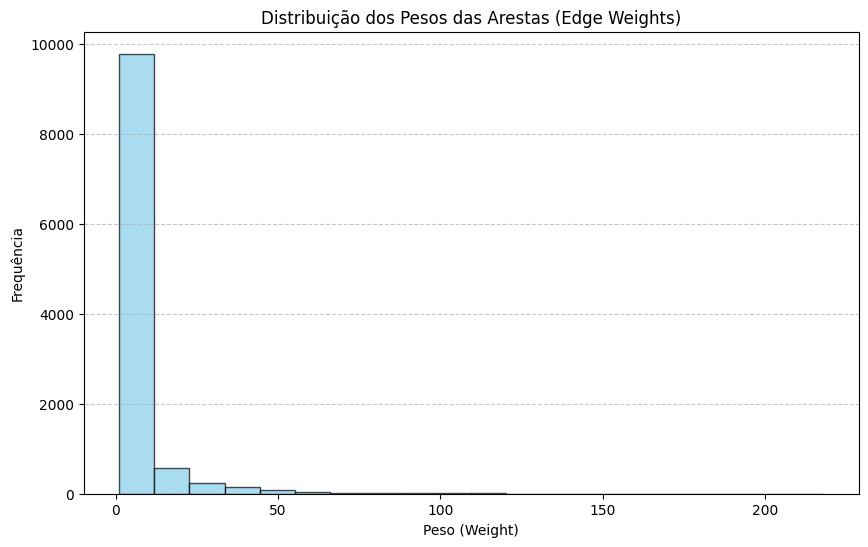

In [5]:
# 2. Extrair os pesos das arestas
# Se a aresta não tiver o atributo 'weight', usamos 1 como padrão
weights = [data.get('weight', 1) for u, v, data in current_graph.edges(data=True)]

# 3. Criar o histograma
plt.figure(figsize=(10, 6))
plt.hist(weights, bins=20, color='skyblue', edgecolor='black', alpha=0.7)

# Customização do gráfico
plt.title('Distribuição dos Pesos das Arestas (Edge Weights)')
plt.xlabel('Peso (Weight)')
plt.ylabel('Frequência')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibir
plt.show()

# Filter graphs

In [6]:
# constants
RAW_DATASET_PATH = "data/raw/"
INTERIM_DATASET_PATH = "data/interim/"
GRAPH_PATH = f"{INTERIM_DATASET_PATH}graphs/"
PROCESSED_DATASET_PATH = "data/processed/"

In [14]:
def filter_edges(caminho_entrada, caminho_saida, threshold=1):
    """
    Abre um grafo, remove arestas com peso igual a 1 e salva o resultado.
    """
    try:
        print("============================================")
        print(f"Processando o grafo: {caminho_entrada}")
        # 1. Carregar o grafo (ajuste a função de leitura conforme o formato do seu arquivo)
        # Ex: nx.read_graphml, nx.read_adjlist, nx.read_edgelist
        G = nx.read_gexf(caminho_entrada)
        
        print(f"Grafo lido com {G.number_of_edges()} arestas.")

        # 2. Identificar arestas com peso 1
        # Criamos uma lista para evitar erros de mutação durante a iteração
        arestas_para_remover = [
            (u, v) for u, v, d in G.edges(data=True) 
            if d.get('weight') <= threshold
        ]

        # 3. Remover as arestas
        G.remove_edges_from(arestas_para_remover)
        
        print(f"Removidas {len(arestas_para_remover)} arestas. Restantes: {G.number_of_edges()}")

        # 4. Salvar o novo grafo
        nx.write_gexf(G, caminho_saida)
        print(f"Grafo salvo com sucesso em: {caminho_saida}")
        
    except Exception as e:
        print(f"Erro ao processar o grafo: {e}")

In [15]:
labels_dict = {
   "bigram_shift": ['I', 'O', 'total'],
   "odd_man_out": ["C", "O", "total"],
   "sentence_length": ["0", "1", "2", "3", "4", "5", "total"]
}
for dataset_name, labels in labels_dict.items():
  for label in labels:

    filter_edges(f"{GRAPH_PATH}complete/g_{label}_{dataset_name}.gexf", f"{GRAPH_PATH}filtered/g_{label}_{dataset_name}.gexf", threshold=10)

Processando o grafo: data/interim/graphs/complete/g_I_bigram_shift.gexf
Grafo lido com 10938 arestas.
Removidas 9688 arestas. Restantes: 1250
Grafo salvo com sucesso em: data/interim/graphs/filtered/g_I_bigram_shift.gexf
Processando o grafo: data/interim/graphs/complete/g_O_bigram_shift.gexf
Grafo lido com 10760 arestas.
Removidas 9522 arestas. Restantes: 1238
Grafo salvo com sucesso em: data/interim/graphs/filtered/g_O_bigram_shift.gexf
Processando o grafo: data/interim/graphs/complete/g_total_bigram_shift.gexf
Grafo lido com 14367 arestas.
Removidas 13118 arestas. Restantes: 1249
Grafo salvo com sucesso em: data/interim/graphs/filtered/g_total_bigram_shift.gexf
Processando o grafo: data/interim/graphs/complete/g_C_odd_man_out.gexf
Grafo lido com 11394 arestas.
Removidas 10410 arestas. Restantes: 984
Grafo salvo com sucesso em: data/interim/graphs/filtered/g_C_odd_man_out.gexf
Processando o grafo: data/interim/graphs/complete/g_O_odd_man_out.gexf
Grafo lido com 11365 arestas.
Removida

# Investigate json leght

In [ ]:
# constants
RAW_DATASET_PATH = "data/raw/"
INTERIM_DATASET_PATH = "data/interim/"
PROCESSED_DATASET_PATH = "data/processed/"
GRAPH_PATH = f"{INTERIM_DATASET_PATH}graphs/"
COMPLETE_GRAPH_PATH = f"{GRAPH_PATH}complete/"
FILTERED_GRAPH_PATH = f"{GRAPH_PATH}filtered/"
DATASETS_NAMES = ["bigram_shift", "odd_man_out", "sentence_length"]

model_ckpt = "bert-base-uncased"



In [24]:
import csv

labels = dict()
# for dataset_name in DATASETS_NAMES:
for dataset_name in  ["odd_man_out_1_000"]:

    print(f"Processing dataset: {dataset_name}")
    # 1. Carregar o arquivo .txt (ajuste o caminho conforme necessário)
    # O separador costuma ser tabulação ou espaço, dependendo da versão
    df = pd.read_csv(
        f"{RAW_DATASET_PATH}{dataset_name}.txt",
        sep="\t",
        names=["split", "label", "text"],
        quoting=csv.QUOTE_NONE
    )

    print(f"Dataset '{dataset_name}' carregado com {len(df)} amostras.")

    # 2. Filtrar apenas o que você deseja (ex: apenas o split de treino 'tr')
    df = df.drop(columns=["split"])

    # 3. Criar o Dataset do Hugging Face (como feito no notebook Emotions.ipynb)
    dataset = Dataset.from_pandas(df.reset_index(drop=True))

    # 4. Mapear as labels para ClassLabel (essencial para o LLM-MRI)
    class_names = [str(x) for x in sorted(dataset.unique("label"))]
    labels[dataset_name] = class_names
    class_feature = features.ClassLabel(names=class_names)
    dataset = dataset.map(lambda x: {"label": class_feature.str2int(str(x["label"]))})
    dataset = dataset.cast(
        features.Features({"label": class_feature, "text": dataset.features["text"]})
    )

    # 5. Processar as áreas de ativação usando o LLM-MRI

    umap = UMAP(n_components=2, random_state=42, gridsize=15)
    llm_mri = ActivationAreas(
        model=model_ckpt, device="cpu", dataset=dataset, reduction_method=umap
    )
    llm_mri.process_activation_areas(
        # save_raw_path="data/dados_hf_brutos",
        # save_reduced_path="data/reduzidos.pt",
        save_jsonl_path=f"{INTERIM_DATASET_PATH}/{dataset_name}_features.json"
    )

    for label in class_names:
        current_graph = llm_mri.get_graph(label)
        nx.write_gexf(
            current_graph, f"{PROCESSED_DATASET_PATH}/g_{label}_{dataset_name}.gexf"
        )

    total_graph = llm_mri.get_graph(class_names)
    nx.write_gexf(total_graph, f"{PROCESSED_DATASET_PATH}/g_total_{dataset_name}.gexf")

Processing dataset: odd_man_out_1_000


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Saving raw features in extract_features format to: data/interim//odd_man_out_1_000_features.json, length of dataset: 1000...
Exporting features in extract_features format to: data/interim//odd_man_out_1_000_features.json...
JSONL file saved successfully!


/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/f-msc2026/ra256352/Documents/pos/code/master_degree_lab/venv/lib64/python3.13/site-packages/umap/u

In [25]:
df

,label,text
0,C,His regret was not in taking the life ...
1,C,"Besides the engines , the police departm..."
2,C,"This is awkward , as the daydream ends ..."
3,C,"My only concern , but it 's a mild on..."
4,O,Foul Ole Ron peered suspiciously into a ...
...,...,...
995,O,"He crowded her , caging her in with hi..."
996,O,' It 's brass monkeys out here . '
997,C,"Her hands were everywhere , assuring his..."
998,O,""" Follow me , "" the cockatiel said , ..."


In [29]:
import json
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
import csv


labels = {
   "bigram_shift": ['I', 'O', 'total'],
   "odd_man_out": ["C", "O", "total"],
   "sentence_length": ["0", "1", "2", "3", "4", "5", "total"]
}

for dataset_name in ["odd_man_out_1_000"]:
    print("====================================================")
    print(f"Carregando rótulos do dataset: {dataset_name}")
    print("====================================================")

    # 1. Carregar apenas os Rótulos do bigram_shift.txt (ignorando os splits antigos)
    labels = []

    with open(f"{RAW_DATASET_PATH}/{dataset_name}.txt", "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split("\t")
            if len(parts) >= 3:
                # Ignoramos parts[0] (o split original 'tr', 'va', 'te')
                # O label 'I' significa Invertido, 'O' significa Original
                label = 1 if parts[1] == 'I' else 0 
                labels.append(parts[1])

    y = np.array(labels)

    # 2. Carregar as Ativações do JSONL gerado pelo ActivationAreas
    activations_per_layer = {} 

    with open(f"{INTERIM_DATASET_PATH}/{dataset_name}_features.json", "r", encoding="utf-8") as f:
        for line_idx, line in enumerate(f):
            data = json.loads(line)
            
            layers_data = data["features"][0]["layers"]
            
            for layer in layers_data:
                layer_idx = layer["index"]
                layer_values = layer["values"]
                
                if layer_idx not in activations_per_layer:
                    activations_per_layer[layer_idx] = []
                    
                activations_per_layer[layer_idx].append(layer_values)

    # 3. Criar novos splits e treinar o Probe para CADA camada
    print("Resultados do Probing (Acurácia por Camada com Novo Split):")
    print("-" * 55)

    # O random_state garante que o split seja reprodutível em futuras execuções
    # O stratify=y garante que a proporção de classes se mantenha no treino e teste
    results_list = []

    for layer_idx in sorted(activations_per_layer.keys()):
        X = np.array(activations_per_layer[layer_idx])
        
        # Criando um novo split: 80% para treino do probe, 20% para teste
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.20, random_state=42, stratify=y
        )
        
        print("Camada", len(X_train[0]), "features - Treinando o Probe...")
        print("Camada", len(y_train), "features - Treinando o Probe...")

        # Treinando o Linear Probe
        probe = LogisticRegression(max_iter=1000, class_weight='balanced')
        probe.fit(X_train, y_train)
        
        # Avaliando
        predictions = probe.predict(X_test)
        acc = accuracy_score(y_test, predictions)
        precision = precision_score(y_test, predictions, average='weighted', zero_division=0)
        recall = recall_score(y_test, predictions, average='weighted', zero_division=0)
        f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
        
        # Armazenar resultados para DataFrame
        results_list.append({
            'layer': layer_idx,
            'accuracy': acc,
            'precision': precision,
            'recall': recall,
            'f1_score': f1,
            'n_train_samples': len(y_train),
            'n_test_samples': len(y_test),
            'n_features': X.shape[1]
        })
        
        print(f"Camada {layer_idx:02d}: Acurácia de {acc * 100:.2f}%")

    # 4. Criar DataFrame com os resultados
    df_probing_results = pd.DataFrame(results_list)

    # 5. Salvar DataFrame em CSV
    output_path = f'{PROCESSED_DATASET_PATH}/probing_{dataset_name}_results.csv'
    df_probing_results.to_csv(output_path, index=False)
    print(f"\n✓ Resultados salvos em: {output_path}")

    # 6. Exibir resumo estatístico
    print("\n" + "="*55)
    print("Resumo Estatístico dos Resultados:")
    print("="*55)
    print(df_probing_results[['layer', 'accuracy', 'precision', 'recall', 'f1_score']].describe())

    # 7. Exibir o DataFrame completo
    print("\n" + "="*55)
    print("Tabela Completa de Resultados:")
    print("="*55)
    display(df_probing_results)

Carregando rótulos do dataset: odd_man_out_1_000
Resultados do Probing (Acurácia por Camada com Novo Split):
-------------------------------------------------------
Camada 768 features - Treinando o Probe...
Camada 800 features - Treinando o Probe...
Camada 00: Acurácia de 50.00%
Camada 768 features - Treinando o Probe...
Camada 800 features - Treinando o Probe...
Camada 01: Acurácia de 50.00%
Camada 768 features - Treinando o Probe...
Camada 800 features - Treinando o Probe...
Camada 02: Acurácia de 45.50%
Camada 768 features - Treinando o Probe...
Camada 800 features - Treinando o Probe...
Camada 03: Acurácia de 46.50%
Camada 768 features - Treinando o Probe...
Camada 800 features - Treinando o Probe...
Camada 04: Acurácia de 53.50%
Camada 768 features - Treinando o Probe...
Camada 800 features - Treinando o Probe...
Camada 05: Acurácia de 51.00%
Camada 768 features - Treinando o Probe...
Camada 800 features - Treinando o Probe...
Camada 06: Acurácia de 53.00%
Camada 768 features - T

,layer,accuracy,precision,recall,f1_score,n_train_samples,n_test_samples,n_features
0,0,0.500,0.250000,0.500,0.333333,800,200,768
1,1,0.500,0.500000,0.500,0.495917,800,200,768
2,2,0.455,0.454959,0.455,0.454877,800,200,768
3,3,0.465,0.464828,0.465,0.464344,800,200,768
4,4,0.535,0.535032,0.535,0.534895,800,200,768
5,5,0.510,0.510016,0.510,0.509804,800,200,768
6,6,0.530,0.530108,0.530,0.529577,800,200,768
7,7,0.535,0.535172,0.535,0.534430,800,200,768
8,8,0.560,0.560024,0.560,0.559956,800,200,768
9,9,0.535,0.535088,0.535,0.534709,800,200,768


# Compare Grid with Graph

In [ ]:
labels = dict()
# for dataset_name in DATASETS_NAMES:
for dataset_name in  ["bigram_shift_2_000"]:

    print(f"Processing dataset: {dataset_name}")
    # 1. Carregar o arquivo .txt (ajuste o caminho conforme necessário)
    # O separador costuma ser tabulação ou espaço, dependendo da versão
    df = pd.read_csv(
        f"{RAW_DATASET_PATH}{dataset_name}.txt",
        sep="\t",
        names=["split", "label", "text"],
        quoting=csv.QUOTE_NONE
    )

    print(f"Dataset '{dataset_name}' carregado com {len(df)} amostras.")

    # 2. Filtrar apenas o que você deseja (ex: apenas o split de treino 'tr')
    df = df.drop(columns=["split"])

    # 3. Criar o Dataset do Hugging Face (como feito no notebook Emotions.ipynb)
    dataset = Dataset.from_pandas(df.reset_index(drop=True))

    # 4. Mapear as labels para ClassLabel (essencial para o LLM-MRI)
    class_names = [str(x) for x in sorted(dataset.unique("label"))]
    labels[dataset_name] = class_names
    class_feature = features.ClassLabel(names=class_names)
    dataset = dataset.map(lambda x: {"label": class_feature.str2int(str(x["label"]))})
    dataset = dataset.cast(
        features.Features({"label": class_feature, "text": dataset.features["text"]})
    )

    # 5. Processar as áreas de ativação usando o LLM-MRI

    umap = UMAP(n_components=2, random_state=42, gridsize=15)
    llm_mri = ActivationAreas(
        model=model_ckpt, device="cpu", dataset=dataset, reduction_method=umap
    )
    llm_mri.process_activation_areas(
        # save_raw_path="data/dados_hf_brutos",
        # save_reduced_path="data/reduzidos.pt",
        # save_jsonl_path=f"{INTERIM_DATASET_PATH}/{dataset_name}_features.json"
    )

    for label in class_names:
        current_graph = llm_mri.get_graph(label)
        nx.write_gexf(
            current_graph, f"{COMPLETE_GRAPH_PATH}/g_{label}_{dataset_name}.gexf"
        )

    total_graph = llm_mri.get_graph(class_names)
    nx.write_gexf(total_graph, f"{COMPLETE_GRAPH_PATH}/g_total_{dataset_name}.gexf")